# 4. Criteria and scoring

Every criterion becomes a component in $[0, 1]$ — a band, a saturating function, or a
ramp — and the components are composed into one number.

This notebook covers the shapes, the composition, and **two traps that are easy to fall
into and hard to notice**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from oroscope import scoring

## The three shapes

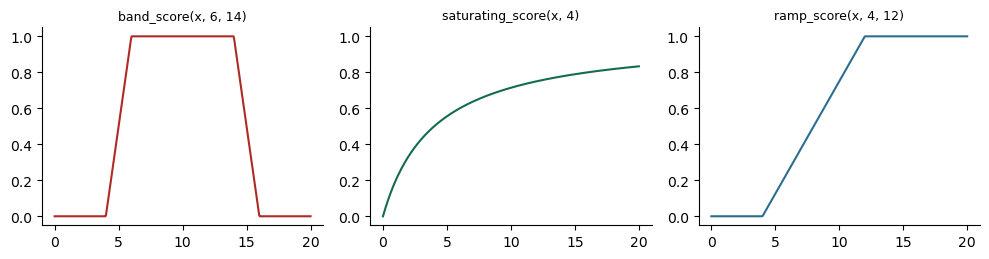

In [2]:
x = np.linspace(0, 20, 400)
fig, axes = plt.subplots(1, 3, figsize=(10, 2.7))

axes[0].plot(x, scoring.band_score(x, 6, 14), color="#B02A25")
axes[0].set_title("band_score(x, 6, 14)", fontsize=9)

axes[1].plot(x, scoring.saturating_score(x, 4), color="#146B54")
axes[1].set_title("saturating_score(x, 4)", fontsize=9)

axes[2].plot(x, scoring.ramp_score(x, 4, 12), color="#2C6E8F")
axes[2].set_title("ramp_score(x, 4, 12)", fontsize=9)

for ax in axes:
    ax.set_ylim(-0.05, 1.05)
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

A **band** is for a quantity with an optimum on both sides. Column depth is the
motivating case: the tau must be *produced*, which needs rock, and must *escape*, which
limits how much.

A **saturating** score is for "more is better with diminishing returns and no natural
maximum" — accepted solid angle.

## Trap 1: a saturating score with the wrong scale stops discriminating

`solid_angle_half_sr` defaults to 0.05 sr, which suits GRAND. An experiment looking
across a canyon sees 0.2–1.5 sr, and against that the term saturates and carries no
information at all.

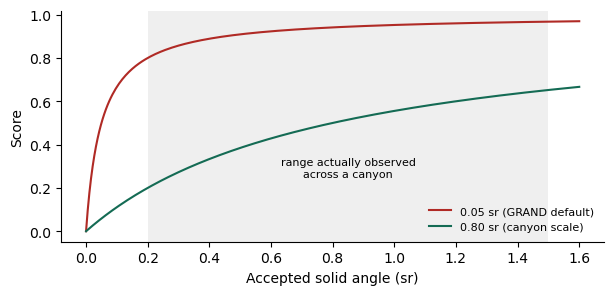

Over 0.2-1.5 sr the default spans 0.168 of score,
against 0.452 at the canyon scale.


In [3]:
omega = np.linspace(0.0, 1.6, 300)
fig, ax = plt.subplots(figsize=(7, 3))
for half, c, lbl in ((0.05, "#B02A25", "0.05 sr (GRAND default)"),
                     (0.80, "#146B54", "0.80 sr (canyon scale)")):
    ax.plot(omega, scoring.saturating_score(omega, half), color=c, label=lbl)
ax.axvspan(0.2, 1.5, color="#999", alpha=0.15, lw=0)
ax.text(0.85, 0.25, "range actually observed\nacross a canyon", ha="center", fontsize=8)
ax.set_xlabel("Accepted solid angle (sr)")
ax.set_ylabel("Score")
ax.legend(frameon=False, fontsize=8, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

print("Over 0.2-1.5 sr the default spans "
      f"{scoring.saturating_score(1.5, 0.05) - scoring.saturating_score(0.2, 0.05):.3f} of score,")
print("against "
      f"{scoring.saturating_score(1.5, 0.8) - scoring.saturating_score(0.2, 0.8):.3f} "
      "at the canyon scale.")

## Trap 2: a product score has no safe threshold

The default composition is a **product**. Multiply six components each in $[0,1]$ and
the result piles up near zero, so a threshold anywhere in the middle sits on a cliff.

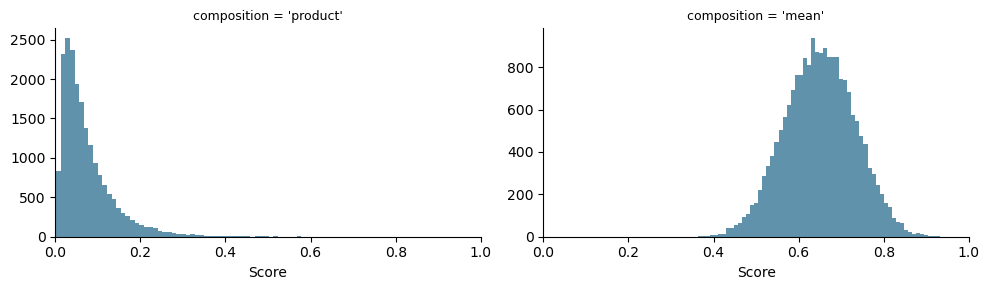

min_score 0.00  keeps 100.0% of candidates
min_score 0.10  keeps  23.9% of candidates
min_score 0.20  keeps   5.1% of candidates
min_score 0.35  keeps   0.6% of candidates
min_score 0.50  keeps   0.1% of candidates


In [4]:
rng = np.random.default_rng(0)
parts = {f"c{i}": rng.uniform(0.3, 1.0, 20000) for i in range(6)}

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, mode in zip(axes, ("product", "mean")):
    total = scoring.compose(parts, mode)
    ax.hist(total, bins=60, color="#2C6E8F", alpha=0.75)
    ax.set_title(f"composition = '{mode}'", fontsize=9)
    ax.set_xlabel("Score")
    ax.set_xlim(0, 1)
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

total = scoring.compose(parts, "product")
for cut in (0.0, 0.1, 0.2, 0.35, 0.5):
    print(f"min_score {cut:.2f}  keeps {100 * (total >= cut).mean():5.1f}% of candidates")

Measured on a real search, that cliff took the reported capacity from 65 268 detector
positions at `min_score` 0.0, to 10 437 at 0.35, to **zero** at 0.5. A result that swings
by that much across a plausible range of a threshold is a result about the threshold.

**Prefer ranking sites and taking the best $N$** over thresholding a product. A weighted
geometric mean also spreads the distribution.

## Scoring candidates

`score_candidates` takes the scan's observables and returns both the total and the named
components — so a weak site can be *attributed* rather than merely ranked.

In [5]:
obs = {
    "cells": np.array([12, 40, 3]),
    "solid_angle_sr": np.array([0.10, 0.90, 0.05]),
    "mean_distance_m": np.array([2.0e4, 3.0e4, 6.0e4]),
    "max_depth_gcm2": np.array([8.0e5, 4.0e6, 2.0e5]),
}

total, parts = scoring.score_candidates(obs, {"solid_angle_half_sr": 0.3})
print("component scores:")
for name, vals in sorted(parts.items()):
    print(f"  {name:>14}: " + "  ".join(f"{v:5.3f}" for v in vals))
print("\n         total: " + "  ".join(f"{v:5.3f}" for v in total))

component scores:
           depth: 1.000  1.000  1.000
     solid_angle: 0.250  0.750  0.143

         total: 0.250  0.750  0.143


## Where to go next

- **[5. GRAND and TAMBO](05_grand_and_tambo.ipynb)** — the same engine, two
  experiments, and what actually differs between them.

---

*Part of the [Oroscope](https://github.com/mbustama/oroscope) tutorials. Previous: [The physics toolkit](03_physics_toolkit.ipynb). Next: [GRAND and TAMBO](05_grand_and_tambo.ipynb). Full API reference: [oroscope docs](https://mbustama.github.io/oroscope/functions.html).*